<a href="https://colab.research.google.com/github/YUH-2006/Mon-AI/blob/main/Nh%C3%B3m_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Khai báo các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 2. Đọc file dữ liệu (Đảm bảo bạn đã upload file train.csv lên Colab)
df = pd.read_csv('train.csv')
print("Đã nạp dữ liệu thành công! Kích thước tập dữ liệu:", df.shape)

Đã nạp dữ liệu thành công! Kích thước tập dữ liệu: (1460, 81)


   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

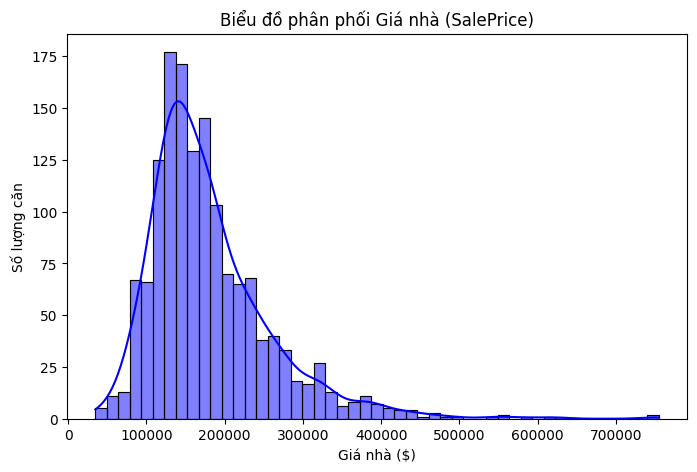

In [ ]:
# Xem 5 dòng đầu tiên
print(df.head())

# Vẽ biểu đồ phân phối của Giá nhà (SalePrice)
plt.figure(figsize=(8, 5))
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title('Biểu đồ phân phối Giá nhà (SalePrice)')
plt.xlabel('Giá nhà ($)')
plt.ylabel('Số lượng căn')
plt.show()

In [ ]:
# 1. Chọn ra các cột đặc trưng dạng số có ảnh hưởng lớn đến giá nhà
features = ['LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
            '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'GarageCars']

X = df[features]
y = df['SalePrice']

# 2. Kiểm tra và điền giá trị thiếu (nếu có) bằng giá trị trung bình (Median)
X = X.fillna(X.median())

# 3. Chia dữ liệu thành 2 phần: 80% để học (Train) và 20% để kiểm tra (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Kích thước tập Train:", X_train.shape)
print("Kích thước tập Test:", X_test.shape)

Kích thước tập Train: (1168, 9)
Kích thước tập Test: (292, 9)


In [ ]:
# Khởi tạo 3 mô hình
model_lr = LinearRegression()
model_dt = DecisionTreeRegressor(random_state=42)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Cho cả 3 mô hình cùng học dữ liệu
model_lr.fit(X_train, y_train)
model_dt.fit(X_train, y_train)
model_rf.fit(X_train, y_train)

print("Đã huấn luyện xong cả 3 mô hình!")

Đã huấn luyện xong cả 3 mô hình!


                Mô hình (Model) Sai số trung bình (MAE) Độ chính xác (R2 Score)
        Hồi quy tuyến tính (LR)              $23,835.65                  80.63%
 Cây quyết định (Decision Tree)              $25,266.90                  76.51%
Rừng ngẫu nhiên (Random Forest)              $18,898.40                  89.10%

--- BIỂU ĐỒ SO SÁNH SAI SỐ MAE (CÀNG THẤP CÀNG TỐT) ---


/tmp/ipykernel_836/2568026870.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=maes, palette='Set2')


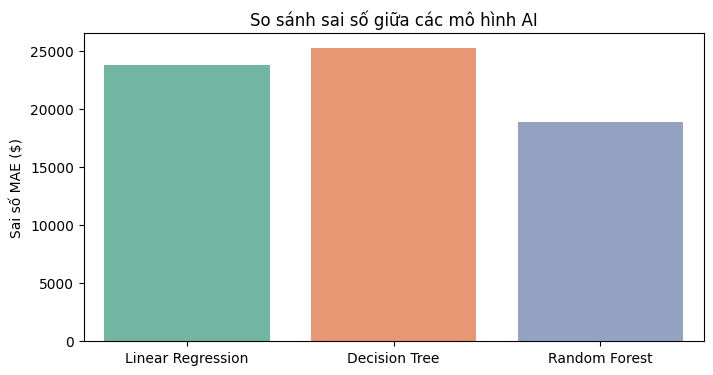

In [ ]:
# 1. Dự đoán trên tập dữ liệu kiểm tra (Test)
pred_lr = model_lr.predict(X_test)
pred_dt = model_dt.predict(X_test)
pred_rf = model_rf.predict(X_test)

# 2. Tính toán các chỉ số lỗi
mae_lr = mean_absolute_error(y_test, pred_lr)
mae_dt = mean_absolute_error(y_test, pred_dt)
mae_rf = mean_absolute_error(y_test, pred_rf)

r2_lr = r2_score(y_test, pred_lr) * 100
r2_dt = r2_score(y_test, pred_dt) * 100
r2_rf = r2_score(y_test, pred_rf) * 100

# 3. In kết quả ra màn hình dưới dạng bảng
results = pd.DataFrame({
    'Mô hình (Model)': ['Hồi quy tuyến tính (LR)', 'Cây quyết định (Decision Tree)', 'Rừng ngẫu nhiên (Random Forest)'],
    'Sai số trung bình (MAE)': [f"${mae_lr:,.2f}", f"${mae_dt:,.2f}", f"${mae_rf:,.2f}"],
    'Độ chính xác (R2 Score)': [f"{r2_lr:.2f}%", f"{r2_dt:.2f}%", f"{r2_rf:.2f}%"]
})
print(results.to_string(index=False))

print("\n--- BIỂU ĐỒ SO SÁNH SAI SỐ MAE (CÀNG THẤP CÀNG TỐT) ---")
# 4. Vẽ biểu đồ cột trực quan so sánh sai số MAE giữa các mô hình
models = ['Linear Regression', 'Decision Tree', 'Random Forest']
maes = [mae_lr, mae_dt, mae_rf]

plt.figure(figsize=(8, 4))
sns.barplot(x=models, y=maes, palette='Set2')
plt.ylabel('Sai số MAE ($)')
plt.title('So sánh sai số giữa các mô hình AI')
plt.show()

In [26]:
import gradio as gr

# Tỷ giá quy đổi cố định (1 USD = 25,000 VNĐ)
TY_GIA = 25000

# Hàm xử lý dự đoán và chọn ảnh minh họa phù hợp với chất lượng
def du_doan_gia_nha_vnd(dien_tich_m2, chat_luong, dieu_kien, nam_xay, tang_1_m2, tang_2_m2, so_tắm, so_ngu, gara):
    # 1. Tính toán bằng mô hình AI
    lot_area_sqft = dien_tich_m2 * 10.76
    first_flr_sqft = tang_1_m2 * 10.76
    second_flr_sqft = tang_2_m2 * 10.76

    input_data = [[lot_area_sqft, chat_luong, dieu_kien, nam_xay, first_flr_sqft, second_flr_sqft, so_tắm, so_ngu, gara]]

    try:
        gia_usd = model_rf.predict(input_data)[0]
    except NameError:
        return "Lỗi: Mô hình chưa được huấn luyện.", "https://via.placeholder.com/600x400.png?text=Error:+Model+Not+Trained"

    gia_vnd = gia_usd * TY_GIA
    ket_qua_tien = f"{gia_vnd:,.0f} VNĐ"

    # 2. Thay đổi kho ảnh mới siêu chuẩn phân khúc
    if chat_luong >= 8:
        # BIỆT THỰ SIÊU SANG (Điểm 8-10): Thiết kế kính sang trọng, đèn ấm
        link_anh = "https://images.unsplash.com/photo-1600596542815-ffad4c1539a9?q=80&w=600&auto=format&fit=crop"
    elif chat_luong >= 5:
        # NHÀ PHỐ HIỆN ĐẠI (Điểm 5-7): Kiểu nhà ống 2-3 tầng thành thị khang trang
        link_anh = "https://images.unsplash.com/photo-1600585154340-be6161a56a0c?q=80&w=600&auto=format&fit=crop"
    else:
        # NHÀ CẤP 4/ĐƠN GIẢN (Điểm dưới 5): Căn nhà nhỏ tối giản, mộc mạc
        link_anh = "https://images.unsplash.com/photo-1513694203232-719a280e022f?q=80&w=600&auto=format&fit=crop"

    return ket_qua_tien, link_anh

# 3. Thiết kế giao diện Web Việt hóa
giao_dien_viet = gr.Interface(
    fn=du_doan_gia_nha_vnd,
    inputs=[
        gr.Number(label="Tổng diện tích khu đất (m²)", value=80),
        gr.Slider(minimum=1, maximum=10, step=1, label="Chất lượng hoàn thiện ngôi nhà (Thang điểm 1-10)", value=4),
        gr.Slider(minimum=1, maximum=10, step=1, label="Điều kiện/Độ mới của nhà (Thang điểm 1-10)", value=4),
        gr.Number(label="Năm xây dựng", value=2000),
        gr.Number(label="Diện tích sàn Tầng 1 (m²)", value=10),
        gr.Number(label="Diện tích sàn Tầng 2 (m²)", value=10),
        gr.Dropdown(choices=[0, 1, 2, 3, 4], label="Số phòng tắm đầy đủ", value=2),
        gr.Dropdown(choices=[0, 1, 2, 3, 4, 5, 6], label="Số phòng ngủ", value=3),
        gr.Dropdown(choices=[0, 1, 2, 3, 4], label="Sức chứa gara ô tô (số lượng xe)", value=1)
    ],
    outputs=[
        gr.Textbox(label="Giá nhà dự đoán (VNĐ)"),
        gr.Image(label="Hình ảnh minh họa kiểu dáng nhà", type="filepath")
    ],
    title="HỆ THỐNG AI DỰ ĐOÁN GIÁ BẤT ĐỘNG SẢN VIỆT NAM",
    description="Nhập các thông số thực tế của ngôi nhà để nhận dự đoán giá thị trường và hình ảnh minh họa mẫu nhà tương ứng."
)

# 4. Kích hoạt Web và tạo Public Link
giao_dien_viet.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9f74fee53e95d93b03.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
